In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey, gaussian
from pathlib import Path
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [53]:
# =============================================================================
# FUNZIONI DI ANALISI AUDIO
# =============================================================================

def power_spectrum(signal, rate):
    """
    Calcola lo spettro di potenza con finestra gaussiana.
    
    Mono: se il segnale è stereo, converte in mono
    Taglio sustain: elimina transitori iniziale/finale (10%-90%)
    Finestra gaussiana: riduce discontinuità ai bordi
    FFT: calcola la trasformata di Fourier
    """
    # 1. Gestione canali
    if np.ndim(signal) > 1:
        signal = signal[:, 0]

    # 2. Taglio dei bordi (10%-90%)
    #n = len(signal)
    #inizio, fine = int(n * 0.1), int(n * 0.9)
    #signal = signal[inizio:fine]
    
    # 3. Finestra gaussiana
    M = len(signal)
    std_dev = M / 8 
    window = gaussian(M, std=std_dev)
    signal = signal * window
    
    # 4. FFT
    n_fft = 65536
    psd = np.abs(np.fft.rfft(signal, n=n_fft))**2
    freqs = np.fft.rfftfreq(n_fft, d=1/rate)

    return freqs, psd


def calcola_fondamentale(signal, sr, fmin=50, fmax=2000):
    """
    Trova la frequenza fondamentale (F0) con algoritmo di voto.
    
    1. FFT ad alta risoluzione (131072 campioni)
    2. Estrae i picchi con energia > 20% del massimo
    3. Genera candidati F0 dalle differenze tra picchi
    4. Voto di maggioranza: sceglie il candidato che spiega più armoniche
    """
    signal = signal - np.mean(signal)
    n_fft = 131072
    mag_spec = np.abs(np.fft.rfft(signal * np.blackman(len(signal)), n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1/sr)

    # 1. Estrazione dei picchi dominanti
    threshold = np.max(mag_spec) * 0.1
    peaks = []
    for i in range(2, len(mag_spec) - 1):
        if mag_spec[i] > threshold and mag_spec[i] > mag_spec[i-1] and mag_spec[i] > mag_spec[i+1]:
            if freqs[i] > fmin:
                peaks.append(freqs[i])
    
    if not peaks: return 0.0
    peaks = sorted(peaks)[:6]  # Prime 6 armoniche potenziali

    # 2. Generazione candidati F0
    candidati = []
    for i in range(len(peaks)):
        for j in range(i + 1, len(peaks)):
            # Distanza tra picchi
            diff = peaks[j] - peaks[i]
            if fmin <= diff <= fmax:
                candidati.append(diff)
            
            # MCD con tolleranza
            a, b = peaks[i], peaks[j]
            while b > 2.0:
                a, b = b, a % b
            if fmin <= a <= fmax:
                candidati.append(a)

    if not candidati: return peaks[0]

    # 3. Voto di maggioranza
    best_f0 = 0
    max_score = -1
    
    for c in candidati:
        score = 0
        for p in peaks:
            resto = p % c
            if resto < c * 0.03 or resto > c * 0.97:
                score += 1
        
        # Bonus: energia vicina al candidato
        idx_c = int(c / (sr / n_fft))
        score += (mag_spec[idx_c] / np.max(mag_spec))

        if score > max_score:
            max_score = score
            best_f0 = c

    return best_f0


def estrai_timbro(freqs, psd, f0, n_armoniche=5):
    """
    Estrae feature timbriche come rapporti (in dB) delle armoniche rispetto alla fondamentale.

    La feature n-esima misura quanto e forte l'armonica n+1 rispetto alla
    fondamentale: 20*log10(amp_n / amp_1). Questo evita di cambiare riferimento
    quando il massimo spettrale non coincide con la fondamentale.
    """
    if f0 <= 0:
        return np.zeros(n_armoniche - 1)
        
    ampiezze = []
    for n in range(1, n_armoniche + 1):
        f_target = n * f0
        idx = np.abs(freqs - f_target).argmin()
        ampiezze.append(np.sqrt(psd[idx])) #perchè potenza P proporzionale a A^2, quindi A = sqrt(P)
    
    ampiezze = np.array(ampiezze)
    feature_db = 20 * np.log10((ampiezze[1:] + 1e-9) / (ampiezze[0] + 1e-9)) 
    return feature_db


def freq_to_note(f, offset_cents=0):
    """
    Converte frequenza in nome nota MIDI.
    """
    if f <= 0: return "N/A"
    
    n = 12 * np.log2(f / 440.0) + 69 - (offset_cents / 100.0)
    n_rounded = int(round(n))
    
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    return f"{notes[n_rounded % 12]}{n_rounded // 12 - 1}"

In [54]:
def window_organ_signal(
    signal,
    sample_rate,
    return_info=False,
    search_step_ms=5.0,
    min_output_ms=80.0,
):
    """
    Individua automaticamente il tratto utile del segnale, lo ritaglia e applica
    una finestra di Tukey per evitare click e leakage.

    signal: Array numpy del segnale audio.
    sample_rate: Frequenza di campionamento.
    return_info: Se True, restituisce anche indici e parametri del taglio.
    search_step_ms: passo della ricerca (ms). Maggiore = piu veloce, meno preciso.
    min_output_ms: durata minima del segnale in uscita (ms).
    return: Segnale ritagliato e finestrato.
    """

    signal = np.asarray(signal)

    # Se il segnale e vuoto, restituisci subito (evita errori di indice).
    if signal.size == 0:
        if return_info:
            return signal, 0, 0, 0.0
        return signal

    # Normalizza in modo robusto anche per dtype diversi da int16.
    if np.issubdtype(signal.dtype, np.integer):
        if np.issubdtype(signal.dtype, np.unsignedinteger):
            info = np.iinfo(signal.dtype)
            mid = (info.max + 1) / 2.0
            signal = (signal.astype(np.float64) - mid) / mid
        else:
            info = np.iinfo(signal.dtype)
            denom = float(max(abs(info.min), info.max))
            signal = signal.astype(np.float64) / denom
    else:
        signal = signal.astype(np.float64, copy=False)

    # Calcola l'inviluppo del segnale (valore assoluto) e lo smussa con una media mobile.
    envelope = np.abs(signal)
    smooth_len = max(3, int(0.01 * sample_rate))
    smooth_kernel = np.ones(smooth_len, dtype=np.float64) / smooth_len
    smoothed = np.convolve(envelope, smooth_kernel, mode='same')

    # Soglia adattiva per individuare la parte attiva.
    peak_level = np.max(smoothed)
    noise_floor = np.percentile(smoothed, 20)
    base_threshold = max(noise_floor * 1.15, peak_level * 0.08)
    threshold = min(base_threshold, peak_level * 0.6)
    active_samples = np.flatnonzero(smoothed >= threshold)

    start_sample = 0
    end_sample = len(signal)

    if active_samples.size > 0:
        # Evita il vincolo fisso di 1s sui segnali corti.
        if len(signal) < sample_rate:
            minimum_start = int(0.10 * len(signal))
        else:
            minimum_start = int(1.0 * sample_rate)
        minimum_start = max(0, min(len(signal) - 1, minimum_start))

        stable_window = max(int(0.06 * sample_rate), 128)
        stable_window = min(stable_window, max(8, len(signal) // 3))
        end_guard = max(int(0.08 * sample_rate), stable_window)

        search_start = max(active_samples[0], minimum_start)
        max_center_start = int(0.65 * len(signal))
        max_valid_start = len(smoothed) - stable_window
        search_stop = min(active_samples[-1] + 1, max_valid_start, max_center_start)

        best_start = search_start
        best_score = np.inf

        if search_stop > search_start:
            search_span = max(1, search_stop - search_start)
            search_step = max(1, int((search_step_ms / 1000.0) * sample_rate))

            for idx in range(search_start, search_stop, search_step):
                segment = smoothed[idx:idx + stable_window]
                if segment.size < stable_window:
                    break

                segment_mean = np.mean(segment)
                if segment_mean < threshold:
                    continue

                segment_std = np.std(segment)
                base_score = segment_std / (segment_mean + 1e-12)

                # Penalita lieve per partenze troppo tarde.
                late_penalty = 0.12 * ((idx - search_start) / search_span)
                score = base_score + late_penalty

                if score < best_score:
                    best_score = score
                    best_start = idx

        start_sample = max(best_start, minimum_start)

        # Usa la parte attiva trovata per stimare la coda utile.
        end_candidate = int(active_samples[-1] + end_guard)
        end_sample = min(len(signal), max(start_sample + stable_window, end_candidate))

    if end_sample <= start_sample:
        trimmed_signal = signal[start_sample:]
    else:
        trimmed_signal = signal[start_sample:end_sample]

    # Fallback: se il taglio e troppo corto/vuoto, usa una finestra centrale minima.
    min_output_samples = max(32, int((min_output_ms / 1000.0) * sample_rate))
    if len(trimmed_signal) < min_output_samples:
        center = len(signal) // 2
        half = min_output_samples // 2
        lo = max(0, center - half)
        hi = min(len(signal), lo + min_output_samples)
        lo = max(0, hi - min_output_samples)
        trimmed_signal = signal[lo:hi]
        start_sample, end_sample = lo, hi

    if len(trimmed_signal) == 0:
        if return_info:
            return trimmed_signal, start_sample, end_sample, 0.0
        return trimmed_signal

    # Sceglie automaticamente la larghezza del fade in base alla durata del taglio.
    fade_samples = max(1, int(0.02 * sample_rate))
    fade_fraction = min(0.2, max(0.02, (2 * fade_samples) / len(trimmed_signal)))
    win = tukey(len(trimmed_signal), alpha=fade_fraction)

    # Applica la finestra e restituisce direttamente il segnale ritagliato.
    windowed_signal = trimmed_signal * win
    if return_info:
        return windowed_signal, start_sample, end_sample, fade_fraction
    return windowed_signal

## Stima della frequenza fondamentale per una nota

La funzione `calcola_fondamentale` stima la F0 cercando picchi spettrali compatibili con una serie armonica. Questa frequenza ha due ruoli distinti:

- permette di assegnare un nome alla nota, usando la funzione `freq_to_note`;
- definisce dove cercare le armoniche usate come feature timbriche, cioe `2*f0`, `3*f0`, ..., `N*f0`.

Il fatto che la distribuzione delle note risulti coerente indica che la stima della F0 e sufficientemente affidabile per identificare le note. Per il clustering, pero, resta importante che le armoniche ricavate da questa F0 descrivano bene il timbro del registro.


La frequenza fondamentale stimata è: 661.01 Hz
Nota stimata: E5


/tmp/ipykernel_7195/4097924375.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(sample_file)


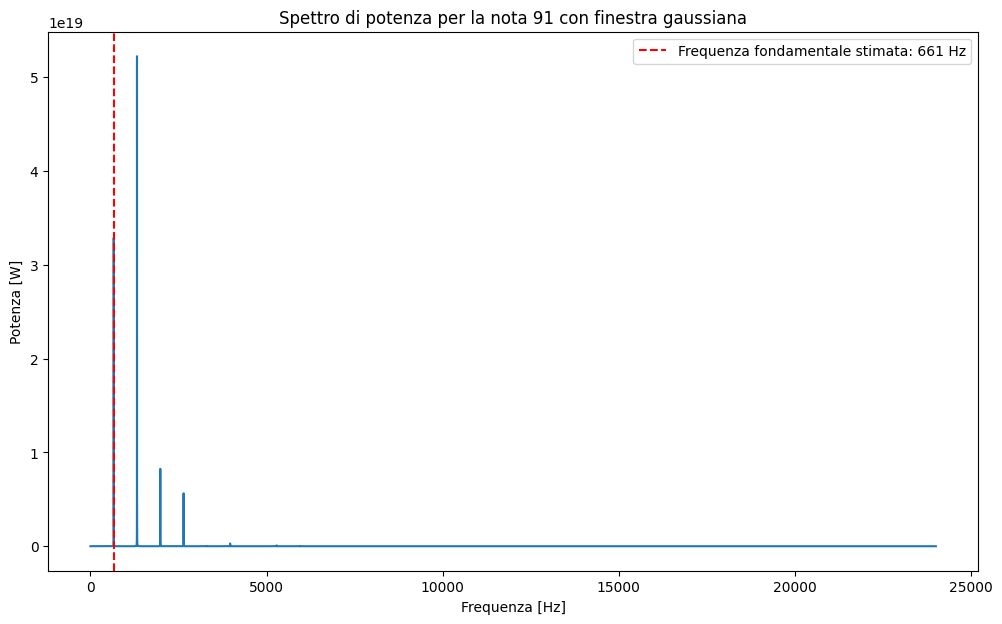

In [55]:
# Esempio: stima della fondamentale sulla stessa nota usando calcola_fondamentale
sample_file = Path('data/note_91.wav')

samplerate, data = wavfile.read(sample_file)
if data.dtype == np.int16:
    data = data / 32768.0

if len(data.shape) > 1:
    signal_mono = np.mean(data, axis=1)
else:
    signal_mono = data

signal_cut = window_organ_signal(signal_mono, samplerate)
signal_cut = signal_cut - np.mean(signal_cut)
# 5. Calcola spettro con finestra gaussiana (lab3)
freqs, psd = power_spectrum(signal_cut, samplerate)

f0 = calcola_fondamentale(signal_cut, samplerate)
print(f"La frequenza fondamentale stimata è: {f0:.2f} Hz")
print(f"Nota stimata: {freq_to_note(f0)}")

plt.figure(figsize=(12,7))
plt.plot(freqs, psd)
plt.axvline(f0, color='r', linestyle='--', label=f'Frequenza fondamentale stimata: {f0:.0f} Hz')
plt.xlabel('Frequenza [Hz]')
plt.ylabel('Potenza [W]')
plt.title('Spettro di potenza per la nota 91 con finestra gaussiana')
plt.legend()
plt.show()

## Analisi di tutte le note

La funzione `process_organ_notes` analizza tute le note nella cartella 'data/' e restituisce un dictionary di NumPy con frequenze, spettro di potenza, samplerate, frequenza fondamentale, nome nota e ampiezze normalizzate delle prime N_ARMONICHE_TIMBRO armoniche. 


In [56]:
N_ARMONICHE_TIMBRO = 10


def process_organ_notes(folder_path, n_armoniche_timbro=N_ARMONICHE_TIMBRO):
    """
    Processa tutte le note dell'organo usando le funzioni:
    - window_organ_signal per ritagliare il segnale
    - calcola_fondamentale per trovare la F0
    - power_spectrum per lo spettro
    - estrai_timbro per le feature timbriche in dB
    - freq_to_note per convertire in nome nota
    """
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        try:
            samplerate, data = wavfile.read(file_path)
            
            # 1. Normalizzazione e gestione Stereo -> Mono
            if data.dtype == np.int16:
                data = data / 32768.0
                
            if len(data.shape) > 1:
                signal = np.mean(data, axis=1)
            else:
                signal = data

            # 2. Ritaglio e windowing (usa la funzione di Acoustics)
            final_signal = window_organ_signal(signal, samplerate)

            # 3. Rimuovi DC (media = 0)
            final_signal = final_signal - np.mean(final_signal)

            # 4. Calcola F0 con algoritmo di voto (lab3)
            f0 = calcola_fondamentale(final_signal, samplerate)
            
            if f0 <= 0:
                print(f"File {file_path.name} scartato: F0 non trovata")
                continue

            # 5. Calcola spettro con finestra gaussiana (lab3)
            freqs, psd = power_spectrum(final_signal, samplerate)

            # 6. Estrai feature timbriche in dB rispetto alla fondamentale e nota
            timbro = estrai_timbro(freqs, psd, f0, n_armoniche=n_armoniche_timbro)
            nome_nota = freq_to_note(f0)
            
            results[file_path.name] = {
                'freq': freqs,
                'psd': psd,
                'rate': samplerate,
                'f0': f0,
                'nota': nome_nota,
                'timbro': timbro
            }
            
        except Exception as e:
            print(f"Errore nel file {file_path.name}: {e}")
            continue

    return results


# Esegui l'elaborazione
results = process_organ_notes('data/', n_armoniche_timbro=N_ARMONICHE_TIMBRO)

print(f'File totali processati: {len(results)}')
print(f'Check psd length: {len(results["note_1.wav"]["psd"])}')
print(f'Sample rate: {results["note_1.wav"]["rate"]}')
print(f'Seconda nota F0: {results["note_2.wav"]["f0"]:.2f} Hz')
print(f'Seconda nota nome: {results["note_2.wav"]["nota"]}')
print(f'Armoniche usate per il timbro: {N_ARMONICHE_TIMBRO} (feature: {N_ARMONICHE_TIMBRO - 1})')


/tmp/ipykernel_7195/1774697326.py:19: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


File totali processati: 280
Check psd length: 32769
Sample rate: 48000
Seconda nota F0: 1481.69 Hz
Seconda nota nome: F#6
Armoniche usate per il timbro: 10 (feature: 9)


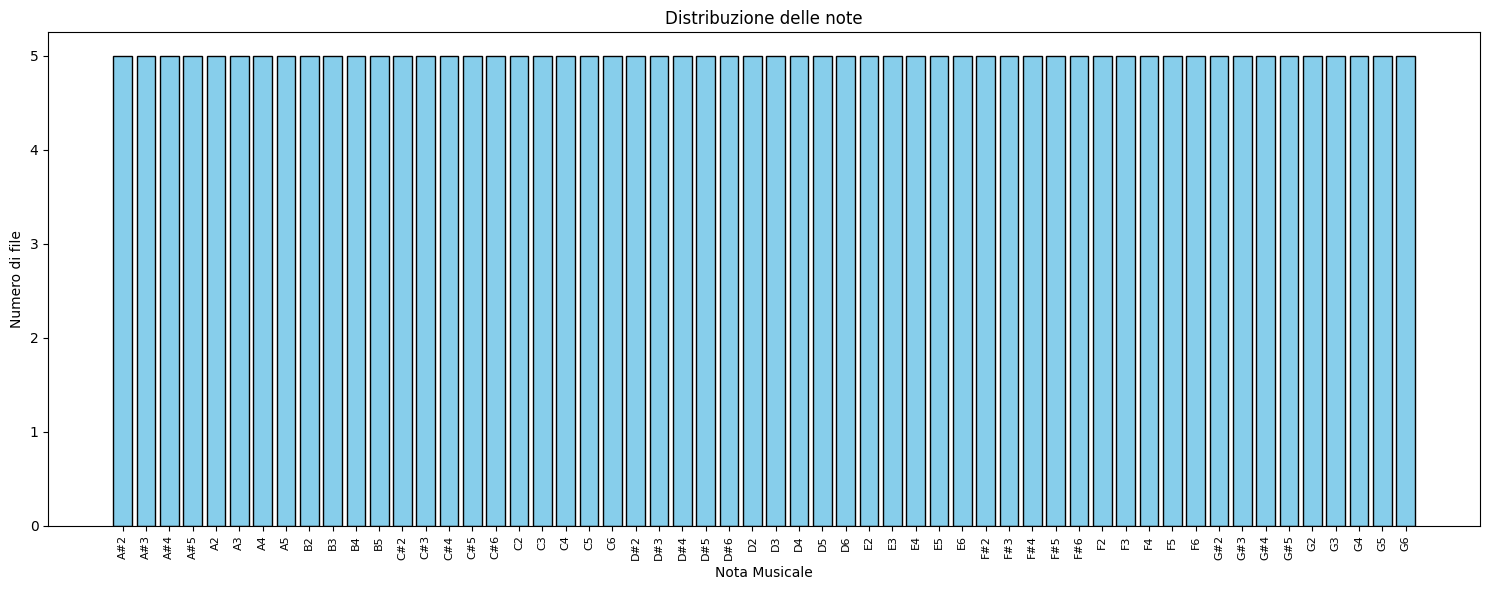

In [57]:
# Estrai tutte le frequenze fondamentali, ignorando eventuali valori a 0 (note non identificate)
f0_values = [data['f0'] for data in results.values() if data['f0'] > 0]
f0_array = np.array(f0_values)  
# 1. Converti in numeri MIDI 
midi_notes = 69 + 12 * np.log2(f0_array / 440) 
# 2. Definisci i nomi delle note 
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'] 
# 3. Funzione per ottenere il nome con l'ottava (es. 60 -> C4) 
def midi_to_name(n): 
    n = int(round(n)) 
    return f"{note_names[n % 12]}{n // 12 - 1}" 
    
# 4. Prepara i dati per l'istogramma  
labels = [midi_to_name(n) for n in midi_notes] 
unique_labels, counts = np.unique(labels,return_counts=True)  

# 1. Crea una figura molto larga (es. 15 pollici di larghezza, 6 di altezza) 
plt.figure(figsize=(15, 6)) 
# 2. Crea il grafico a barre 
plt.bar(unique_labels, counts, color='skyblue', edgecolor='black') 
# 3. Configura le etichette dell'asse X 
plt.xticks( rotation=90, fontsize=8, ha='center') 
plt.xlabel('Nota Musicale') 
plt.ylabel('Numero di file') 
plt.title('Distribuzione delle note') 
# 4. Ottimizza i margini per non tagliare le etichette in basso
plt.tight_layout() 
plt.show()  

## K-Means sui registri

L'obiettivo e raggruppare le registrazioni in 5 cluster timbrici, interpretabili come registri. Il numero 5 viene usato come ipotesi di lavoro per K-Means (ce lo ha detto il prof).

Prima del clustering vengono fatte tre operazioni importanti:

1. le feature sono rapporti armonici in dB rispetto alla fondamentale;
2. le feature vengono centrate per nota, sottraendo la media dei file con la stessa nota stimata;
3. le feature centrate vengono standardizzate con `StandardScaler`, serve perchè così una feature non domina le altre solo perché ha valori numericamente più grandi o più variabili.


Esempio di spiegazione del punto 2. : 

Supponi di avere diversi file classificati come nota Do:
    Do_file_1 → [-6, -12, -20]
    Do_file_2 → [-8, -11, -19]
    Do_file_3 → [-7, -13, -21]
Prima calcoli il timbro medio dei file che hanno la stessa nota stimata, cioè la media delle componenti dei Do:
    media_Do = [-7, -12, -20]
Poi a ogni file Do sottrai questa media:
    Do_file_1 centrato = [-6, -12, -20] - [-7, -12, -20]
                  = [ 1,   0,   0]

    Do_file_2 centrato = [-8, -11, -19] - [-7, -12, -20]
                  = [-1,   1,   1]

    Do_file_3 centrato = [-7, -13, -21] - [-7, -12, -20]
                  = [ 0,  -1,  -1]

Il motivo è che note diverse, per esempio un Do basso e un Do alto, possono avere distribuzioni armoniche diverse anche solo per effetto dell’altezza, della registrazione o della risposta dello strumento. Se fai clustering direttamente sui vettori grezzi, K-Means potrebbe separare i file soprattutto per altezza della nota, non per timbro.


La normalizzazione per nota serve a ridurre l'effetto dell'altezza: confrontiamo quanto ogni registrazione si discosta dal timbro medio della propria nota, invece di mischiare direttamente note basse e note alte.


## K-Means nello spazio completo delle feature

Il clustering finale viene eseguito su `X_kmeans`, cioe sul vettore completo delle feature armoniche in dB, normalizzate per nota e standardizzate.

La cella calcola anche una baseline su `X_raw_kmeans`, cioe sulle feature non centrate per nota, cosi possiamo confrontare se la normalizzazione per nota migliora i conteggi.

Oltre al clustering principale, la cella calcola anche una **baseline** usando `X_raw_kmeans`.
Nel senso che calcoliamo un risultato di confronto: eseguiamo K-Means anche su una versione più semplice dei dati, in modo da capire se le operazioni aggiuntive che ho introdotto portano davvero un miglioramento (mi serviva per capire se aveva senso o meno).
`X_raw_kmeans` contiene le feature timbriche in dB rispetto alla fondamentale, ma **senza la centratura per nota**. Quindi il clustering viene fatto direttamente sui rapporti armonici grezzi, senza sottrarre il timbro medio associato a ciascuna nota stimata.
Il confronto è quindi tra due casi:
- `X_raw_kmeans`: feature timbriche non centrate per nota;
- `X_kmeans`: feature timbriche centrate per nota e poi standardizzate.



Il modello resta K-Means, ma usiamo piu inizializzazioni:

```python
n_init=50
max_iter=500
init='k-means++'
```

Questo riduce solo il rischio che una singola inizializzazione sfavorevole produca una soluzione instabile o un cluster anomalo.


In [58]:
# 1. Usa direttamente il campo 'timbro' gia calcolato da process_organ_notes.
#    Ora contiene i rapporti in dB delle armoniche 2..N_ARMONICHE_TIMBRO rispetto alla fondamentale.
#
#    In questa versione rimuoviamo l'effetto della nota: per ogni nota stimata
#    sottraiamo la media delle feature timbriche dei file con la stessa nota.
#    Non imponiamo cluster bilanciati: usiamo solo la struttura delle note
#    ricavata dalla F0.
X_raw = []
nomi_file = []
note_stimate = []

for file_name, data in results.items():
    if data['f0'] > 0 and 'timbro' in data:
        X_raw.append(data['timbro'])
        nomi_file.append(file_name)
        note_stimate.append(data['nota'])

X_raw = np.array(X_raw)
note_stimate = np.array(note_stimate)
NUMERO_REGISTRI = 5

# Controllo diagnostico: quante occorrenze abbiamo per ogni nota stimata.
note_counts = pd.Series(note_stimate).value_counts().sort_index()
print('Occorrenze per nota stimata:')
print(note_counts)
print(f'Numero di note diverse stimate: {len(note_counts)}')

# Baseline: stesso K-Means sulle feature non centrate, utile per confrontare il cambiamento.
scaler_raw = StandardScaler()
X_raw_kmeans = scaler_raw.fit_transform(X_raw)
kmeans_raw = KMeans(
    n_clusters=NUMERO_REGISTRI,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)
labels_raw = kmeans_raw.fit_predict(X_raw_kmeans)
cluster_counts_raw = pd.Series(labels_raw).value_counts().sort_index()
print('\nConteggi cluster senza normalizzazione per nota:')
print(cluster_counts_raw)

# 2. Normalizzazione per nota: centra le feature dentro ciascun gruppo di note uguali.
X_note_centered = X_raw.copy()
for nota in np.unique(note_stimate):
    idx = note_stimate == nota
    X_note_centered[idx] = X_raw[idx] - X_raw[idx].mean(axis=0)

# Da qui in poi usiamo le feature corrette per nota.
X = X_note_centered

# 3. Standardizziamo le feature armoniche centrate per nota prima del K-Means.
scaler_kmeans = StandardScaler()
X_kmeans = scaler_kmeans.fit_transform(X)

# 4. Applichiamo il K-Means sulle feature normalizzate per nota.
kmeans = KMeans(
    n_clusters=NUMERO_REGISTRI,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)
labels = kmeans.fit_predict(X_kmeans)
cluster_counts = pd.Series(labels).value_counts().sort_index()
print('\nConteggi cluster con normalizzazione per nota:')
print(cluster_counts)

# 5. Stampiamo i risultati.
#print('\n--- RISULTATI CLUSTERING CON NORMALIZZAZIONE PER NOTA ---')
#for name, nota, label in zip(nomi_file, note_stimate, labels):
#    print(f"File: {name} | Nota: {nota} -> Cluster: {label}")


Occorrenze per nota stimata:
A#2    5
A#3    5
A#4    5
A#5    5
A2     5
A3     5
A4     5
A5     5
B2     5
B3     5
B4     5
B5     5
C#2    5
C#3    5
C#4    5
C#5    5
C#6    5
C2     5
C3     5
C4     5
C5     5
C6     5
D#2    5
D#3    5
D#4    5
D#5    5
D#6    5
D2     5
D3     5
D4     5
D5     5
D6     5
E2     5
E3     5
E4     5
E5     5
E6     5
F#2    5
F#3    5
F#4    5
F#5    5
F#6    5
F2     5
F3     5
F4     5
F5     5
F6     5
G#2    5
G#3    5
G#4    5
G#5    5
G2     5
G3     5
G4     5
G5     5
G6     5
Name: count, dtype: int64
Numero di note diverse stimate: 56

Conteggi cluster senza normalizzazione per nota:
0    55
1    74
2    33
3    56
4    62
Name: count, dtype: int64

Conteggi cluster con normalizzazione per nota:
0    64
1    54
2    65
3    42
4    55
Name: count, dtype: int64


## PCA solo per la visualizzazione 2D

Per visualizzare i cluster in un piano applichiamo una PCA a `X_kmeans`, ma solo dopo aver gia eseguito K-Means.

Questo significa che:

- i cluster sono quelli trovati da K-Means nello spazio completo delle feature;
- la PCA serve solo a proiettare i punti in 2 dimensioni;
- i colori del grafico sono le etichette `labels` gia assegnate da K-Means;
- anche i centroidi vengono proiettati con la stessa PCA, cosi possono essere mostrati nello stesso piano.

Il grafico aiuta a leggere la separazione visiva, ma non e la prova definitiva della qualita del clustering, perche la proiezione 2D perde parte dell'informazione originale.


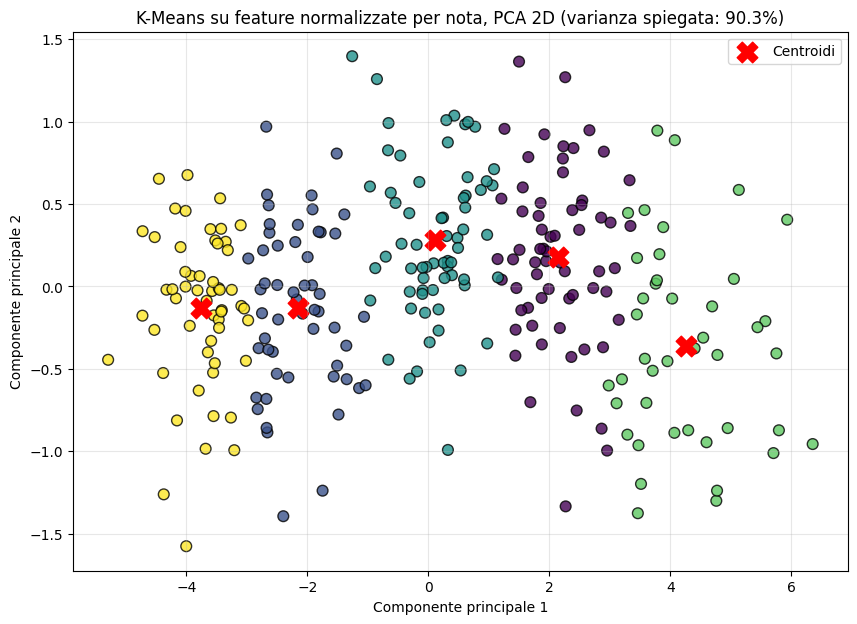

In [59]:
# Riduciamo a 2 dimensioni le feature standardizzate solo per visualizzare i cluster.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_kmeans)
centroids_pca = pca.transform(kmeans.cluster_centers_)
varianza_spiegata = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(10, 7))

# Usiamo i cluster calcolati dal K-Means nello spazio completo delle feature centrate per nota.
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='viridis',
    s=60,
    alpha=0.8,
    edgecolors='k'
)

# Proiettiamo anche i centroidi del K-Means nello stesso piano PCA.
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=220,
    c='red',
    label='Centroidi'
)

plt.title(f'K-Means su feature normalizzate per nota, PCA 2D (varianza spiegata: {varianza_spiegata:.1f}%)')
plt.xlabel('Componente principale 1')
plt.ylabel('Componente principale 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Conteggi dei cluster

Il grafico a barre e la stampa dei conteggi servono come diagnostica.



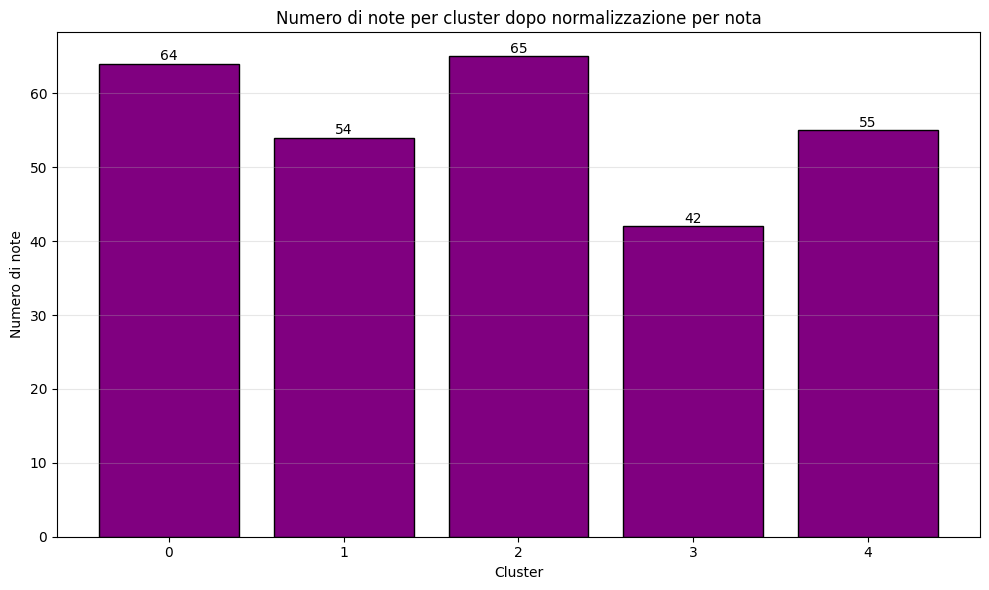

In [60]:
cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='purple', edgecolor='black')
plt.title('Numero di note per cluster dopo normalizzazione per nota')
plt.xlabel('Cluster')
plt.ylabel('Numero di note')
plt.grid(axis='y', alpha=0.3)

# Aggiungiamo il valore sopra ogni barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()

#print('Conteggio per cluster:')
#print(cluster_counts)


## Ispezione dei file assegnati

Questa stampa mostra quali file finiscono in ogni cluster e la distribuzione delle note dentro ciascun cluster. Serve a capire se un cluster sta raccogliendo molte note diverse in modo coerente, oppure se sta assorbendo esempi che dovrebbero appartenere ad altri registri.

Questa parte e utile soprattutto quando i conteggi migliorano ma resta un cluster troppo grande o troppo piccolo.


In [61]:
results_df = pd.DataFrame({'File': nomi_file, 'Nota': note_stimate, 'Cluster': labels})
for i in range(NUMERO_REGISTRI):
    cluster_rows = results_df[results_df['Cluster'] == i]
    cluster_files = cluster_rows['File'].values
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}): {len(cluster_files)}")
    print(cluster_files)
    print('Distribuzione note nel cluster:')
    print(cluster_rows['Nota'].value_counts().sort_index())



Note nel Cluster 0 (Probabile Registro 0): 64
<StringArray>
[  'note_1.wav', 'note_102.wav',  'note_11.wav', 'note_113.wav',
 'note_114.wav', 'note_115.wav', 'note_117.wav', 'note_119.wav',
 'note_120.wav',  'note_13.wav', 'note_142.wav', 'note_149.wav',
 'note_152.wav', 'note_153.wav', 'note_154.wav', 'note_158.wav',
 'note_162.wav', 'note_166.wav', 'note_168.wav', 'note_170.wav',
 'note_174.wav', 'note_181.wav', 'note_182.wav', 'note_185.wav',
 'note_187.wav', 'note_189.wav', 'note_196.wav', 'note_205.wav',
 'note_210.wav', 'note_222.wav', 'note_231.wav', 'note_232.wav',
 'note_242.wav', 'note_246.wav', 'note_250.wav', 'note_252.wav',
 'note_256.wav', 'note_257.wav', 'note_260.wav', 'note_266.wav',
 'note_273.wav',  'note_31.wav',  'note_38.wav',   'note_4.wav',
  'note_40.wav',  'note_43.wav',  'note_46.wav',  'note_47.wav',
  'note_48.wav',  'note_61.wav',  'note_63.wav',  'note_69.wav',
   'note_7.wav',   'note_8.wav',  'note_81.wav',  'note_84.wav',
  'note_85.wav',  'note_87.wa